In [1]:
import os
import glob
from datasets import Dataset, concatenate_datasets
import datetime
import random

/home/lab/.conda/envs/sdg/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load All code files

In [2]:
base_dir = "../../../src/sdg_hub"

blocks = os.path.join(base_dir, "blocks")

configs = os.path.join(base_dir, "configs")

flows = os.path.join(base_dir, "flows")


misc_files = [os.path.join(base_dir, "checkpointer.py") , os.path.join(base_dir, "flow.py"), os.path.join(base_dir, "pipeline.py"), os.path.join(base_dir, "prompts.py"), os.path.join(base_dir, "registry.py"), os.path.join(base_dir, "sdg.py"),
os.path.join(base_dir, "utils", "datautils.py")]

misc_group =  {
    'core_componenets': [os.path.join(base_dir, "flow.py"), os.path.join(base_dir, "pipeline.py"), os.path.join(base_dir, "prompts.py"), os.path.join(base_dir, "registry.py"), os.path.join(base_dir, "sdg.py")],
    'utils': [os.path.join(base_dir, "utils", "datautils.py")],
    'aux_componenets': [os.path.join(base_dir, "checkpointer.py")]
}

document_outline_template = """
sdg_hub is a python package for synthetic data generation using a large language model to train another LLM. 
Code Version: {code_version}
""" # Knolwedge Cutoff Date: {knowledge_cutoff_date}

document_outline_template_custom_msg = """
sdg_hub is a python package for synthetic data generation using a large language model to train another LLM. 
{custom_msg}
Code Version: {code_version}
"""

misc_outline_template = """
sdg_hub is a python package for synthetic data generation using a large language model to train another LLM. 
File Path: {file_path}
Package Path: {package_path}
Code Version: {code_version}
"""

document_outline_prompts = """
sdg_hub is a python package for synthetic data generation using a large language model to train another LLM. 
Prompt Path: {file_path}
Prompt Taxonomy: {prompt_tax}
Code Version: {code_version}
"""

document_outline_flows = """
sdg_hub is a python package for synthetic data generation using a large language model to train another LLM. 
YAML Flow Path: {file_path}
Flow Taxonomy: {flow_tax}
Code Version: {code_version}
"""
today_date = datetime.datetime.now().strftime("%Y-%B-%d")
code_version = "git main branch"

### Load All documents from `docs`

In [18]:
all_docs = glob.glob(os.path.join('../../../docs/blocks/', '**', '*.md'), recursive=True)


doc_code = []
doc_outline = []
for doc in all_docs:
    with open(doc, 'r') as f:
        doc_code.append(f.read())
    doc_outline.append(document_outline_template.format(knowledge_cutoff_date=today_date, code_version=code_version))

In [10]:
icls_slides_paper = {
    "icl_document": '# Knowledge Tuning / Customization of Reasoning Models Slides\n\n## Slide 1 Recaping our sdg_hub **knowledge pipeline**:\nUses `LLMBlocks` and a `FilterBlock`\n\n### Here’s a breakdown of the pipeline flow:\n\n1. **LLMBlock: 3 Types of Summary**\n\n   * This stage has 3 blocks that create three types of summaries from the input content (likely *extractive*, *detailed*, and *atomic facts*).\n   * It serves as the starting point of the pipeline.\n\n2. **LLMBlock: Generate Question-Answer based on qna yaml**\n\n   * Based on the summaries and a `qna.yaml` schema, this block generates structured Q\\&A pairs.\n   * The qna.yaml has seed_examples that act has "template" for teacher model to generate more similar synthetic QA pairs.\n   * The qna.yaml also contains the document outline needed as extra context for teacher model when looking at document chunks (like a title of the document)\n\n3. **LLMBlock: Evaluate Faithfulness**\n\n   * This evaluates the faithfulness (i.e., groundedness of the answer to the document chunk) of the generated Q\\&A pairs against the original document or summary.\n   * It ensures quality control before filtering.\n\n4. **FilterBlock: Filter on Score**\n\n   * This block filters out low-quality or unfaithful Q\\&A pairs based on evaluation scores.\n   * The result is a refined set of high-confidence Q\\&A pairs.\n\n### Summary:\n\nThis slide outlines a **4-stage pipeline** to convert documents into high-quality Q\\&A data:\n\n> *Summarization → QA Generation → Faithfulness Evaluation → Score-based Filtering.*\n\nIt’s a sdg_hub\'s knowledge pipeline (also known as knowledge 1.5) synthetic data generation flow for tuning or evaluating LLMs. Let me know if you\'d like a cleaner version for your presentation or documentation.',
    "icl_query_1": "What are the main stages of the sdg_hub knowledge pipeline?",
    "icl_response_1": 'The main stages of the **sdg\\_hub knowledge pipeline** are:\n\n1. **Summarization (`LLMBlock: 3 Types of Summary`)**\n   Generates three types of summaries from the input content (e.g., extractive, detailed, atomic facts) as the starting point for further processing.\n\n2. **Question-Answer Generation (`LLMBlock: Generate Question-Answer based on qna.yaml`)**\n   Uses the summaries and a structured YAML file (`qna.yaml`) to produce synthetic Q\\&A pairs based on seed examples and document context.\n\n3. **Faithfulness Evaluation (`LLMBlock: Evaluate Faithfulness`)**\n   Assesses how well the generated Q\\&A pairs align with the original content to ensure they are grounded and trustworthy.\n\n4. **Score-based Filtering (`FilterBlock: Filter on Score`)**\n   Filters out low-quality or unfaithful Q\\&A pairs based on evaluation scores, retaining only high-confidence outputs.\n\n**Pipeline Flow:**\n**Summarization → QA Generation → Faithfulness Evaluation → Score-based Filtering**\nThis process produces clean, high-quality synthetic Q\\&A data for reasoning model customization.',
    "icl_query_2": "What role does the 'qna.yaml' file play in the QA generation block of the sdg_hub pipeline?",
    "icl_response_2": 'In the **QA Generation** block of the `sdg_hub` pipeline, the **`qna.yaml`** file plays a **critical role as the schema and guide** for generating structured question-answer (Q\\&A) pairs. Specifically, it serves three key functions:\n\n1. **Template Provider (seed\\_examples):**\n   It contains *seed examples*—predefined Q\\&A pairs that act as templates. The teacher model uses these to learn the desired Q\\&A structure, tone, and reasoning style. This ensures consistency and quality in the synthetic Q\\&A data.\n\n2. **Schema Definition:**\n   It defines the *format and variables* required for generating valid Q\\&A pairs. This helps align the generated content with downstream data processing or fine-tuning needs.\n\n3. **Document Context Enricher (outline):**\n   It includes the *document outline* (e.g., document title, section headers) that gives additional context to the teacher model when generating Q\\&A from specific document chunks.\n\n### In short:\n\nThe `qna.yaml` guides **how** the questions and answers should be generated, **what structure** they should follow, and **what context** to consider—making it essential for generating relevant, high-quality, and grounded Q\\&A data in the pipeline.',
    "icl_query_3": "How does the sdg_hub pipeline ensure the quality of generated question-answer pairs?",
    "icl_response_3": 'The `sdg_hub` pipeline ensures the quality of generated question-answer (Q\\&A) pairs through a **multi-stage filtering and validation process** designed to maximize **faithfulness, relevance, and clarity**. Here’s how each stage contributes:\n\n---\n\n### ✅ **1. Summarization Stage (LLMBlock: 3 Types of Summary)**\n\n* **Purpose**: Generates diverse summaries (*extractive, detailed, atomic*) of the document chunks.\n* **Why it helps**: These summaries offer multiple grounded perspectives for downstream question generation, ensuring the model works with high-context inputs.\n\n---\n\n### ✅ **2. QA Generation Stage (LLMBlock: Generate Q\\&A)**\n\n* **Purpose**: Uses a structured `qna.yaml` schema to generate Q\\&A pairs from summaries.\n* **Why it helps**:\n\n  * `seed_examples` in the YAML file guide the teacher model to follow the expected Q\\&A format and logic.\n  * Additional outline metadata (e.g., document title or section) improves context awareness and specificity.\n\n---\n\n### ✅ **3. Faithfulness Evaluation (LLMBlock: Evaluate Faithfulness)**\n\n* **Purpose**: Assesses whether the generated answers are **faithful** to the source content (document or summary).\n* **Why it helps**: Prevents hallucinated or irrelevant responses from being included in the dataset. This ensures **grounded, source-aligned Q\\&A generation**.\n\n---\n\n### ✅ **4. Score-Based Filtering (FilterBlock: Filter on Score)**\n\n* **Purpose**: Filters out Q\\&A pairs below a certain faithfulness or quality threshold.\n* **Why it helps**: Ensures only **high-confidence, accurate** data is retained for use in model training or evaluation.\n\n---\n\n### 🎯 **In Summary:**\n\n> The `sdg_hub` pipeline uses a layered approach of summarization, schema-driven generation, automated faithfulness evaluation, and score-based filtering to systematically ensure **high-quality, faithful, and contextually rich Q\\&A pairs** for reasoning model customization.'
}

document_outline_msgs = {
    "papers/lab": "Instructlab and sdg_hub synthetic data generation paper.",
    "slides/enablement_sessions": "Workshop session on sdg_hub and instructlab sdg. This document contains the summarized slides, and workshop recording transcript including the question and answers.",
    "slides/knowledge_session": "Workshop session on knowledge tuning using instuctlab sdg. This document contains the summarized slides showing what instructlab is, what is knowledge ingestion problem in LLM customization, how to use instructlab sdg to tune a LLM on your document/knowledge. This include writing qna yaml, for knowledge and skills data generation."
}
lab_paper = glob.glob(os.path.join('../../../docs/papers/', '**', '*.md'), recursive=True)
slides = glob.glob(os.path.join('../../../docs/slides/', '**', '*.md'), recursive=True)
doc_outline = []
doc_text = []
doc_type = []
for doc in lab_paper + slides:
    with open(doc, 'r') as f:
        doc_text.append(f.read())
    pattern_found = False
    for pattern in document_outline_msgs.keys():
        if pattern in doc:
            pattern_found = True
            doc_type.append(pattern)
            doc_outline.append(document_outline_template_custom_msg.format(custom_msg=document_outline_msgs[pattern], knowledge_cutoff_date=today_date, code_version=code_version))
            break
    if not pattern_found:
        print(doc)

ds_doc = Dataset.from_dict({'document_outline': doc_outline, 'document': doc_text, 'type': doc_type, 'domain': ['python package']*len(doc_text)})
ds = ds_doc.map(lambda x: icls_slides_paper)
ds = ds.map(lambda x: {'token_size': len(tokenizer.encode(x['document']))}, batched=False, num_proc=16)
new_ds = []
for e in ds:
    if e['token_size'] > 8000:
        new_docs = chunk_document(e['document'], 16384, 8000)
        new_ds.extend([{'document': doc, 'type': e['type'], 'domain': e['domain'], 'token_size': len(tokenizer.encode(doc)), 'document_outline': e['document_outline'], 'icl_document': e['icl_document'], 'icl_query_1': e['icl_query_1'], 'icl_response_1': e['icl_response_1'], 'icl_query_2': e['icl_query_2'], 'icl_response_2': e['icl_response_2'], 'icl_query_3': e['icl_query_3'], 'icl_response_3': e['icl_response_3']} for doc in new_docs])
    else:
        new_ds.append(e)
new_ds = Dataset.from_list(new_ds)
new_ds = new_ds.map(lambda x: {'document': x['document'].replace('<think>', '<nemotron_think>').replace('</think>', '</nemotron_think>')}, batched=False, num_proc=16)
new_ds.to_json("slides_paper_seed_data.jsonl", orient='records', lines=True)


Map: 100%|██████████| 10/10 [00:00<00:00, 2661.53 examples/s]
num_proc must be <= 10. Reducing num_proc to 10 for dataset of size 10.


[03:47:52] WARNING  num_proc must be <= 10. Reducing num_proc to 10 for dataset of size 10.   ]8;id=139054;file:///home/lab/.conda/envs/sdg/lib/python3.10/site-packages/datasets/arrow_dataset.py\arrow_dataset.py]8;;\:]8;id=81094;file:///home/lab/.conda/envs/sdg/lib/python3.10/site-packages/datasets/arrow_dataset.py#3005\3005]8;;\

Map (num_proc=10): 100%|██████████| 10/10 [00:00<00:00, 46.88 examples/s]
num_proc must be <= 13. Reducing num_proc to 13 for dataset of size 13.


[03:47:53] WARNING  num_proc must be <= 13. Reducing num_proc to 13 for dataset of size 13.   ]8;id=144322;file:///home/lab/.conda/envs/sdg/lib/python3.10/site-packages/datasets/arrow_dataset.py\arrow_dataset.py]8;;\:]8;id=508149;file:///home/lab/.conda/envs/sdg/lib/python3.10/site-packages/datasets/arrow_dataset.py#3005\3005]8;;\

Creating json from Arrow format: 100%|██████████| 1/1 [00:00<00:00, 149.58ba/s]


426321

In [11]:
icls_notebooks = {
    "icl_document": '# 📘 Sample Python Notebook: Data Exploration\n\nThis notebook demonstrates a simple workflow for loading, inspecting, and visualizing a dataset using Python.\n\n---\n\n## 🧰 Step 1: Import Required Libraries\n\n```python\nimport pandas as pd\nimport matplotlib.pyplot as plt\nimport seaborn as sns\n````\n\n---\n\n## 📂 Step 2: Load the Dataset\n\n```python\ndf = pd.read_csv(\'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv\')\n```\n\n---\n\n## 🔍 Step 3: Explore the Data\n\n```python\ndf.head()\n```\n\n```python\ndf.describe()\n```\n\n---\n\n## 📊 Step 4: Visualize Feature Distributions\n\n```python\nsns.pairplot(df, hue=\'species\')\nplt.suptitle("Iris Dataset Pairplot", y=1.02)\nplt.show()\n```\n\n---\n\n## ✅ Conclusion\n\nIn this simple notebook, we:\n\n* Loaded the Iris dataset.\n* Performed a basic data inspection.\n* Visualized feature relationships using Seaborn.\n\nYou can now proceed to build a classifier or conduct further statistical analysis!\n\n---',
    "icl_query_1": "What is the purpose of using `sns.pairplot(df, hue='species')` in the notebook, and what insights can it provide about the Iris dataset?",
    "icl_response_1": "The line `sns.pairplot(df, hue='species')` creates a grid of scatter plots (pairwise plots) for each pair of numerical features in the Iris dataset. The `hue='species'` argument colors the points based on the flower species, allowing you to visually distinguish how each species is distributed across different feature pairs.\n\n**Purpose and Insights:**\n\n* Helps in **visual exploratory data analysis** by showing relationships between features like `sepal_length`, `sepal_width`, `petal_length`, and `petal_width`.\n* Reveals **patterns or clusters** that might indicate which features are most useful for distinguishing between species.\n* Makes it easier to **identify correlations** or potential outliers.\n* Aids in **model selection**, since features that clearly separate classes in these plots are likely useful for classification.\n\nFor example, in the Iris dataset, you'll typically see that `petal_length` and `petal_width` clearly separate *setosa* from the other species, which is a key insight before modeling.",
     "icl_query_2": "After calling `df.describe()`, what kind of summary statistics do you get, and how might they help you understand the dataset better before modeling?",
    "icl_response_2": "The `df.describe()` function in pandas provides **summary statistics** for all numeric columns in the dataset. It includes:\n\n* **count** – Number of non-null values\n* **mean** – Average of the column\n* **std** – Standard deviation (spread of the data)\n* **min** – Minimum value\n* **25%**, **50% (median)**, **75%** – Quartile values\n* **max** – Maximum value\n\n---\n\n**How these statistics help:**\n\n* ✅ **Understand feature scale**: Knowing the range (min to max) and standard deviation helps with feature scaling and model prep.\n* ✅ **Spot outliers**: Large gaps between quartiles or a big difference between mean and median may suggest skew or outliers.\n* ✅ **Compare features**: You can see which features vary more and might carry more predictive power.\n* ✅ **Check for data issues**: For example, if `count` is lower than expected, there may be missing values.\n\n**Example:**\n\nFor `petal_length`, you might see:\n\n```\ncount    150.000000  \nmean       3.758000  \nstd        1.765298  \nmin        1.000000  \n25%        1.600000  \n50%        4.350000  \n75%        5.100000  \nmax        6.900000\n```\n\nThis tells you:\n\n* Petal lengths range from **1.0 to 6.9 cm**.\n* There's a wide spread (std \\~ 1.76), which may be useful for classification.", 
    "icl_query_3": "What are the first two functions used to explore the dataset after loading it, and what does each function reveal?",
    "icl_response_3" : "After loading the dataset using `pd.read_csv()`, the notebook uses the following two functions to explore the data:\n\n1. **`df.head()`**\n\n   * Displays the **first 5 rows** of the dataset.\n   * Useful for getting a **quick look at the structure** of the data, including column names, data types, and sample values.\n   * Helps verify that the dataset was loaded correctly.\n\n2. **`df.describe()`**\n\n   * Provides **summary statistics** for all numerical columns.\n   * Includes metrics like count, mean, standard deviation, min, max, and quartiles.\n   * Useful for understanding the **distribution and range** of each feature and spotting potential outliers.\n\n---\n\nThese two functions are commonly used as the **first step in exploratory data analysis** to quickly assess the dataset's content and quality." 
    }

document_outline_msgs = {
    "skill": "Notebook on how to use sdg_hub to generate synthetic data for teaching a student model a skill/task.",
    "knowledge": "Notebook on how to use sdg_hub to generate synthetic data for teaching a model user's document/knowledge.",
}
notebooks = glob.glob(os.path.join('../../../docs/examples/', '**', '*.md'), recursive=True)
doc_outline = []
doc_text = []
doc_type = []
for doc in notebooks:
    with open(doc, 'r') as f:
        doc_text.append(f.read())
    pattern_found = False
    for pattern in document_outline_msgs.keys():
        if pattern in doc:
            pattern_found = True
            doc_type.append(pattern)
            doc_outline.append(document_outline_template_custom_msg.format(custom_msg=document_outline_msgs[pattern], knowledge_cutoff_date=today_date, code_version=code_version))
            break
    if not pattern_found:
        print(doc)

ds_doc = Dataset.from_dict({'document_outline': doc_outline, 'document': doc_text, 'type': doc_type, 'domain': ['python package']*len(doc_text)})
ds = ds_doc.map(lambda x: icls_notebooks)
ds = ds.map(lambda x: {'token_size': len(tokenizer.encode(x['document']))}, batched=False, num_proc=16)
new_ds = []
for e in ds:
    if e['token_size'] > 8000:
        new_docs = chunk_document(e['document'], 16384, 8000)
        new_ds.extend([{'document': doc, 'type': e['type'], 'domain': e['domain'], 'token_size': len(tokenizer.encode(doc)), 'document_outline': e['document_outline'], 'icl_document': e['icl_document'], 'icl_query_1': e['icl_query_1'], 'icl_response_1': e['icl_response_1'], 'icl_query_2': e['icl_query_2'], 'icl_response_2': e['icl_response_2'], 'icl_query_3': e['icl_query_3'], 'icl_response_3': e['icl_response_3']} for doc in new_docs])
    else:
        new_ds.append(e)
new_ds = Dataset.from_list(new_ds)
print(new_ds.filter(lambda x: '<think>' in x['document']))
new_ds = new_ds.map(lambda x: {'document': x['document'].replace('<think>', '<nemotron_think>').replace('</think>', '</nemotron_think>')}, batched=False, num_proc=16)
new_ds.to_json("notebooks_seed_data.jsonl", orient='records', lines=True)

Map: 100%|██████████| 12/12 [00:00<00:00, 2978.20 examples/s]
num_proc must be <= 12. Reducing num_proc to 12 for dataset of size 12.


[03:48:11] WARNING  num_proc must be <= 12. Reducing num_proc to 12 for dataset of size 12.   ]8;id=145524;file:///home/lab/.conda/envs/sdg/lib/python3.10/site-packages/datasets/arrow_dataset.py\arrow_dataset.py]8;;\:]8;id=274967;file:///home/lab/.conda/envs/sdg/lib/python3.10/site-packages/datasets/arrow_dataset.py#3005\3005]8;;\

Filter: 100%|██████████| 13/13 [00:00<00:00, 5025.43 examples/s]
num_proc must be <= 13. Reducing num_proc to 13 for dataset of size 13.


Dataset({
    features: ['document_outline', 'document', 'type', 'domain', 'icl_document', 'icl_query_1', 'icl_response_1', 'icl_query_2', 'icl_response_2', 'icl_query_3', 'icl_response_3', 'token_size'],
    num_rows: 2
})


           WARNING  num_proc must be <= 13. Reducing num_proc to 13 for dataset of size 13.   ]8;id=912107;file:///home/lab/.conda/envs/sdg/lib/python3.10/site-packages/datasets/arrow_dataset.py\arrow_dataset.py]8;;\:]8;id=365831;file:///home/lab/.conda/envs/sdg/lib/python3.10/site-packages/datasets/arrow_dataset.py#3005\3005]8;;\

Creating json from Arrow format: 100%|██████████| 1/1 [00:00<00:00, 202.71ba/s]


333996

### ICL

In [12]:
icls_knowledge = {
  "icl_document": '# Documentation: src/sdg_hub/blocks/block.py - Base Block Class\n\nThis module defines the abstract base class (`Block`) for all computational units within the Synthetic Data Generation (SDG) Hub framework. It provides core functionalities common to all blocks, such as configuration loading and input validation, particularly for blocks that utilize templating.\n\n---\n\n## Module Overview\n\nThe `block.py` module is central to the `sdg_hub`\'s architecture. It ensures that all specialized blocks adhere to a common interface and inherit baseline functionalities.\n\n* **SPDX-License-Identifier**: `Apache-2.0` (Indicates the licensing terms for this file).\n\n---\n\n## Imports\n\nThe module utilizes several standard Python libraries, third-party libraries, and local project modules:\n\n* **Standard Library**:\n    * `abc.ABC`: Used to declare abstract base classes.\n    * `collections.ChainMap`: To combine multiple dictionaries for template rendering, allowing defaults or overrides.\n    * `typing.Any, Dict, Optional`: For type hinting.\n* **Third-Party**:\n    * `jinja2.Template, UndefinedError`: For handling Jinja2 templating and associated errors.\n    * `yaml`: For parsing YAML configuration files.\n* **Local Project Modules**:\n    * `..registry.BlockRegistry`: Imports the `BlockRegistry` to allow block classes to register themselves, making them discoverable by the framework.\n    * `..logger_config.setup_logger`: Imports a function to set up a structured logger for the module.\n\n---\n\n## Logger Configuration\n\nA logger instance is initialized for this module to facilitate consistent logging practices:\n\n```python\nlogger = setup_logger(__name__)\n```\n\n---\n\n## The `Block` Class\n\nThe `Block` class is the cornerstone of the framework\'s modular design.\n\n```python\n@BlockRegistry.register("Block")\nclass Block(ABC):\n    """Base abstract class for all blocks in the system.\n\n    This class provides common functionality for block validation and configuration loading.\n    All specific block implementations should inherit from this class.\n    """\n\n    def __init__(self, block_name: str) -> None:\n        self.block_name = block_name\n\n    @staticmethod\n    def _validate(prompt_template: Template, input_dict: Dict[str, Any]) -> bool:\n        # ... (implementation details below)\n        pass\n\n    def _load_config(self, config_path: str) -> Optional[Dict[str, Any]]:\n        # ... (implementation details below)\n        pass\n```',
  "icl_query_1": "What is the role of `block.py` in the sdg_hub framework?",
  "icl_response_1": 'The `block.py` module defines the **base class `Block`**, which serves as the **foundation for all computational units (blocks)** in the `sdg_hub` synthetic data generation framework. Its role is to provide:\n\n### Core Functionality\n\n* **Standard interface**: Ensures that all blocks follow a common structure.\n* **Templating support**: Includes input validation for blocks using Jinja2 templates.\n* **Configuration loading**: Handles reading block configuration from YAML files.\n\n### Architectural Significance\n\n* **Modular design**: Enables plug-and-play components by letting custom blocks inherit from `Block`.\n* **Auto-registration**: Uses `BlockRegistry` to register each block class, so the framework can dynamically discover and instantiate them.\n\n### Summary\n\n`block.py` is the **backbone** of the block system in `sdg_hub`, enforcing consistency, facilitating templating, and managing block configuration—all of which are essential for building flexible and reusable synthetic data generation pipelines.',
  "icl_query_2": "How does the `Block` class support templating and configuration in sdg_hub?",
  "icl_response_2": "The `Block` class in `sdg_hub` supports **templating** and **configuration** through two key methods: `_validate` and `_load_config`. Here's how each contributes:\n\n---\n\n## 1. **Templating Support** — `_validate` method\n\n```python\n@staticmethod\ndef _validate(prompt_template: Template, input_dict: Dict[str, Any]) -> bool:\n```\n\n### Purpose:\n\nValidates whether the given input dictionary provides all necessary variables required by a **Jinja2 template**.\n\n### How it works:\n\n* Uses `jinja2.Template` to try rendering the template with `input_dict`.\n* Catches `UndefinedError` to detect missing variables or mismatches.\n* Returns `True` if the template renders successfully, `False` otherwise.\n\n### Use case:\n\nEnsures blocks using text templates (e.g. prompts for LLMs) are provided valid and complete input data before execution.\n\n---\n\n## 2. **Configuration Support** — `_load_config` method\n\n```python\ndef _load_config(self, config_path: str) -> Optional[Dict[str, Any]]:\n```\n\n### Purpose:\n\nLoads block-specific configuration from a **YAML file**.\n\n### How it works:\n\n* Reads the YAML file located at `config_path`.\n* Parses it into a Python dictionary using `yaml.safe_load()`.\n* Returns the config dict or `None` if the file is not found or invalid.\n\n### Use case:\n\nAllows block behavior (e.g., generation parameters, prompt templates, filters) to be specified externally without modifying code.\n\n---\n\n## 📦 Summary\n\n| Feature           | Method         | Purpose                                                               |\n| ----------------- | -------------- | --------------------------------------------------------------------- |\n| **Templating**    | `_validate`    | Ensures the Jinja2 template has all required inputs before rendering. |\n| **Configuration** | `_load_config` | Reads YAML config files into structured Python dictionaries.          |\n\nThese methods enable each block to be **self-contained, configurable, and robust**, supporting the modular and reusable design of the SDG Hub framework.",
  "icl_query_3": "What does `@BlockRegistry.register(\"Block\")` do in the block.py file?",
  "icl_response_3": 'The line:\n\n```python\n@BlockRegistry.register("Block")\n```\n\nis a **decorator** that registers the `Block` class with the `BlockRegistry` under the name `"Block"`.\n\n---\n\n## What It Means\n\n* `BlockRegistry` is a **registry pattern implementation** in `sdg_hub` used to **track and manage all available block types**.\n* The `.register("Block")` method:\n\n  * Takes the class name (`"Block"`) as a key.\n  * Returns a decorator that stores the decorated class (`Block`) in an internal registry dictionary.\n\n---\n\n## Why This Matters\n\n* **Automatic Discovery**: When the framework builds a pipeline, it can dynamically instantiate blocks based on config files that reference the registered name (`"Block"`).\n* **Modularity**: You can define new block types (e.g., `LLMBlock`, `FilterBlock`) and register them similarly without modifying the core system.\n* **Plug-and-Play Architecture**: The registry enables a pluggable architecture, where blocks can be swapped or extended easily.\n\n---\n\n## Example (Conceptual)\n\n```python\nclass BlockRegistry:\n    _registry = {}\n\n    @classmethod\n    def register(cls, name):\n        def decorator(block_cls):\n            cls._registry[name] = block_cls\n            return block_cls\n        return decorator\n```\n\nSo after:\n\n```python\n@BlockRegistry.register("Block")\nclass Block(ABC):\n    ...\n```\n\nThe registry contains:\n\n```python\nBlockRegistry._registry == {"Block": <class \'Block\'>}\n```\n\n---\n\n## Summary\n\n`@BlockRegistry.register("Block")` allows the `Block` class to be:\n\n* Discoverable by name (`"Block"`) across the SDG Hub framework\n* Instantiated dynamically during pipeline execution\n* Extended and reused in a modular way without hardcoding class references.'
  }

icl_code = {
  "icl_document": '\nsdg_hub is a package for synthetic data generation using a large language model to train another LLM. \nFile Path: ../../../src/sdg_hub/blocks/llmblock.py\nPackage Path: sdg_hub.blocks.llmblock\n\n```python\n# SPDX-License-Identifier: Apache-2.0\n"""Utility blocks for dataset manipulation and transformation.\n\nThis module provides various utility blocks for operations like column manipulation,\ndata population, selection, and transformation of datasets. These blocks are designed\nto work with the Hugging Face datasets library and provide common data processing\nfunctionality.\n\nThe module includes blocks for:\n\nData Filtering and Selection:\n- "FilterByValueBlock": Filter datasets based on column values with support for:\n  * Multiple comparison operations (equals, contains, etc.)\n  * Data type conversion\n  * Batch processing\n  * Custom filtering conditions\n\nData Population and Configuration:\n- "SamplePopulatorBlock": Populate datasets with configuration data:\n  * Load data from multiple YAML configuration files\n  * Map configuration data to dataset columns\n  * Support for post-fix naming\n  * Batch processing capabilities\n\nColumn Operations:\n- "SelectorBlock": Map values between columns based on choice mapping\n- "CombineColumnsBlock": Concatenate multiple columns with custom separators\n- "FlattenColumnsBlock": Transform wide format to long format datasets\n- "DuplicateColumns": Create copies of existing columns with new names\n- "RenameColumns": Rename columns using a mapping dictionary\n- "SetToMajorityValue": Set column values to the most frequent value\n\nAdvanced Processing:\n- "IterBlock": Apply blocks iteratively for multiple generations:\n  * Support for any block type\n  * Configurable number of iterations\n  * Custom generation parameters\n  * Batch processing support\n\nAll blocks support:\n- Batch processing for improved performance\n- Error handling and logging\n- Type hints and comprehensive documentation\n- Integration with the BlockRegistry\n- Standardized interface through the Block base class\n"""\n\n# Standard\nimport operator\nfrom typing import Any, Callable, Dict, List, Optional, Type, Union\n\n# Third Party\nfrom datasets import Dataset\n\n# Local\nfrom .block import Block\nfrom ..registry import BlockRegistry\nfrom ..logger_config import setup_logger\n\nlogger = setup_logger(__name__)\n\n\n@BlockRegistry.register("FilterByValueBlock")\nclass FilterByValueBlock(Block):\n    """A block for filtering datasets based on column values.\n\n    This block allows filtering of datasets using various operations (e.g., equals, contains)\n    on specified column values, with optional data type conversion. It supports both\n    single value and list of values for filtering.\n\n    Parameters\n    ----------\n    block_name : str\n        Name of the block.\n    filter_column : str\n        The name of the column in the dataset to apply the filter on.\n    filter_value : Union[Any, List[Any]]\n        The value(s) to filter by. Can be a single value or a list of values.\n    operation : Callable[[Any, Any], bool]\n        A binary operator from the operator module (e.g., operator.eq, operator.contains)\n        that takes two arguments and returns a boolean.\n    convert_dtype : Optional[Union[Type[float], Type[int]]], optional\n        Type to convert the filter column to. Can be either float or int.\n        If None, no conversion is performed.\n    **batch_kwargs : Dict[str, Any]\n        Additional kwargs for batch processing.\n    """\n\n    def __init__(\n        self,\n        block_name: str,\n        filter_column: str,\n        filter_value: Union[Any, List[Any]],\n        operation: Callable[[Any, Any], bool],\n        convert_dtype: Optional[Union[Type[float], Type[int]]] = None,\n        **batch_kwargs: Dict[str, Any],\n    ) -> None:\n        """Initialize a new FilterByValueBlock instance.\n\n        Parameters\n        ----------\n        block_name : str\n            Name of the block.\n        filter_column : str\n            The name of the column in the dataset to apply the filter on.\n        filter_value : Union[Any, List[Any]]\n            The value(s) to filter by. Can be a single value or a list of values.\n        operation : Callable[[Any, Any], bool]\n            A binary operator from the operator module (e.g., operator.eq, operator.contains)\n            that takes two arguments and returns a boolean.\n        convert_dtype : Optional[Union[Type[float], Type[int]]], optional\n            Type to convert the filter column to. Can be either float or int.\n            If None, no conversion is performed.\n        **batch_kwargs : Dict[str, Any]\n            Additional kwargs for batch processing.\n\n        Returns\n        -------\n        None\n\n        Raises\n        ------\n        ValueError\n            If the operation is not from the operator module.\n        """\n        super().__init__(block_name=block_name)\n        # Validate that operation is from operator module\n        if operation.__module__ != "_operator":\n            logger.error("Invalid operation: %s", operation)\n            raise ValueError("Operation must be from operator module")\n\n        self.value = filter_value if isinstance(filter_value, list) else [filter_value]\n        self.column_name = filter_column\n        self.operation = operation\n        self.convert_dtype = convert_dtype\n        self.num_procs = batch_kwargs.get("num_procs", 1)\n\n    def _convert_dtype(self, sample: Dict[str, Any]) -> Dict[str, Any]:\n        """Convert the data type of the filter column.\n\n        Parameters\n        ----------\n        sample : Dict[str, Any]\n            The sample dictionary containing the column to convert.\n\n        Returns\n        -------\n        Dict[str, Any]\n            The sample with converted column value.\n        """\n        try:\n            sample[self.column_name] = self.convert_dtype(sample[self.column_name])\n        except ValueError as e:\n            logger.error(\n                "Error converting dtype: %s, filling with None to be filtered later", e\n            )\n            sample[self.column_name] = None\n        return sample\n\n    def generate(self, samples: Dataset) -> Dataset:\n        """Generate filtered dataset based on specified conditions.\n\n        Parameters\n        ----------\n        samples : Dataset\n            The input dataset to filter.\n\n        Returns\n        -------\n        Dataset\n            The filtered dataset.\n        """\n        if self.convert_dtype:\n            samples = samples.map(\n                self._convert_dtype,\n                num_proc=self.num_procs,\n            )\n\n        if self.operation == operator.contains:\n            samples = samples.filter(\n                lambda x: self.operation(self.value, x[self.column_name]),\n                num_proc=self.num_procs,\n            )\n\n        samples = samples.filter(\n            lambda x: x[self.column_name] is not None,\n            num_proc=self.num_procs,\n        )\n\n        samples = samples.filter(\n            lambda x: any(\n                self.operation(x[self.column_name], value) for value in self.value\n            ),\n            num_proc=self.num_procs,\n        )\n\n        return samples',
  "icl_query_1": "What is the purpose of the FilterByValueBlock in the sdg_hub package?",
  "icl_response_1": 'The **purpose of the `FilterByValueBlock`** in the `sdg_hub` package is to **filter rows in a dataset based on the values in a specific column**, using a specified comparison operation.\n\n### Key Capabilities:\n\n* **Flexible filtering logic**: Supports single or multiple values for comparison.\n* **Custom operations**: Uses Python\'s `operator` functions (e.g., `operator.eq`, `operator.contains`) to define the filtering rule.\n* **Optional type conversion**: Converts column values to `int` or `float` before filtering if needed.\n* **Robust batch processing**: Works efficiently on large datasets using parallelization.\n* **Error handling**: Handles data conversion issues gracefully by logging and skipping invalid entries.\n\n### Use Case Example:\n\nYou could use `FilterByValueBlock` to:\n\n* Filter a dataset to only include rows where `"category" == "science"`\n* Filter numeric columns to include only rows where a `"score" > 50` (after converting to `int`)\n* Apply partial string matches using `operator.contains`\n\nThis block is part of a modular system in `sdg_hub` designed to preprocess data before it\'s used to train or evaluate large language models.',
  "icl_query_2": "How does FilterByValueBlock ensure valid operations for filtering?",
  "icl_response_2": 'The `FilterByValueBlock` ensures **valid operations for filtering** through **explicit validation during initialization**:\n\n### Validation Mechanism:\n\nInside the `__init__` method:\n\n```python\nif operation.__module__ != "_operator":\n    logger.error("Invalid operation: %s", operation)\n    raise ValueError("Operation must be from operator module")\n```\n\n### 🔍 What This Does:\n\n* It **checks if the `operation` provided comes from Python’s built-in `operator` module**, which contains safe, known binary functions like `operator.eq`, `operator.contains`, etc.\n* If the `operation` is not from the `operator` module, it:\n\n  * Logs an error\n  * Raises a `ValueError`\n\n### Why This Matters:\n\n* **Prevents arbitrary or unsafe functions** from being used as filter logic.\n* Guarantees consistency and safety when filtering rows, especially in batch processing.\n* Ensures the block only uses well-defined, boolean-returning operations suitable for dataset filtering.\n\n### Example of valid use:\n\n```python\noperation=operator.eq  # accepted\n```\n\n### Example of invalid use:\n\n```python\noperation=lambda x, y: x + y  # rejected\n```\n\nIn summary, the validation enforces that only standard, safe operations from the `operator` module can be used for filtering, which improves reliability and reduces runtime errors.',
  "icl_query_3": "What happens if data type conversion fails in FilterByValueBlock?",
  "icl_response_3": 'If **data type conversion fails** in `FilterByValueBlock`, it is **safely handled and logged**, ensuring the block does not crash.\n\n### Where this happens:\n\nInside the `_convert_dtype` method:\n\n```python\ntry:\n    sample[self.column_name] = self.convert_dtype(sample[self.column_name])\nexcept ValueError as e:\n    logger.error("Error converting dtype: %s, filling with None to be filtered later", e)\n    sample[self.column_name] = None\n```\n\n### What Happens Step-by-Step:\n\n1. The block attempts to **convert** the value in the specified column (`self.column_name`) to the desired type (e.g., `int`, `float`).\n2. If the conversion **succeeds**, the value is updated.\n3. If the conversion **fails** (e.g., a string like `"abc"` is passed to `int()`):\n\n   * It logs the error with `logger.error(...)`\n   * Sets the value to `None` (marking it for exclusion later)\n\n### Cleanup Later:\n\nAfter conversion, the `generate()` method filters out all samples where the column value is `None`:\n\n```python\nsamples = samples.filter(\n    lambda x: x[self.column_name] is not None,\n    num_proc=self.num_procs,\n)\n```\n\n### Why This is Good:\n\n* Prevents invalid data from disrupting the pipeline.\n* Keeps the filtering logic robust and consistent.\n* Ensures only valid, correctly-typed values are used for filtering.\n\n### In Summary:\n\n> If data type conversion fails, the value is replaced with `None`, logged as an error, and excluded from the final filtered dataset.'
  }

icl_git_history = {
  "icl_document": 'Commit Message: \n\nFix up spellcheck and markdown lint\n\nDisable some markdown linting rules, clean up a bit of trailing\nwhitespace in README.md, and expand the custom spellcheck\nentries.\n\nSigned-off-by: Ben Browning <bbrownin@redhat.com>\n\nFile Path: .spellcheck-en-custom.txt\n\nDiff:\n@@ -1,25 +1,5 @@\n # make spellcheck-sort\n # Please keep this file sorted:\n # SPDX-License-Identifier: Apache-2.0\n-Composable\n-composable\n-customizable\n-Dataflow\n-Datasets\n-dataset\n-datasets\n-icl\n-instructlab\n-jsonl\n-LLM\n-parallelization\n-Reusability\n-Scalability\n-scalable\n-scikit\n sdg\n-src\n Tatsu\n-TODO\n-YAML\n-yaml\n\n\nDate: 2025-03-24 15:31:19-04:00',
  "icl_query_1": "What changes were made to the `.spellcheck-en-custom.txt` file in this commit?",
  "icl_response_1": 'In this commit, the `.spellcheck-en-custom.txt` file was **cleaned up** by **removing multiple custom spellcheck entries**, likely to streamline or refocus the custom dictionary. Specifically, the following words were **deleted**:\n\n* Composable\n* composable\n* customizable\n* Dataflow\n* Datasets\n* dataset\n* datasets\n* icl\n* instructlab\n* jsonl\n* LLM\n* parallelization\n* Reusability\n* Scalability\n* scalable\n* scikit\n* TODO\n* YAML\n* yaml\n\nThe remaining words in the file after the commit are:\n\n* `sdg`\n* `src`\n* `Tatsu`\n\nThis suggests the commit **reduced the custom dictionary entries** significantly, likely to avoid over-permissiveness or to refactor the spellchecking scope.',
  "icl_query_2": "When was this commit made and who authored it?",
  "icl_response_2": "The commit was made on March 24, 2025, at 15:31 (Eastern Time) by Ben Browning, whose email is listed as bbrownin@redhat.com.",
  "icl_query_3": "What was the main purpose of this commit as described in the message?",
  "icl_response_3": 'The main purpose of this commit, as described in the message, was to:\n\n* **Fix spellcheck and markdown lint issues**\n* **Disable some markdown linting rules**\n* **Clean up trailing whitespace in `README.md`**\n* **Expand the custom spellcheck entries**\n\nOverall, the commit focused on improving **code formatting and linting hygiene** by adjusting spellcheck settings and markdown formatting.'
}


In [13]:
block_files = [os.path.join(blocks, f) for f in os.listdir(blocks) if 'init' not in f and 'pycache' not in f]
block_code = []
block_doc_outline = []
for block_file in block_files:
    with open(block_file, 'r') as f:
        block_code.append(f"```python\n{f.read()}\n```")
    package_path = block_file[block_file.find('src/'):].replace('src/', '').replace('.py', '').split('/')
    package_path = '.'.join(package_path)
    block_doc_outline.append(misc_outline_template.format(file_path=block_file, package_path=package_path, knowledge_cutoff_date=today_date, code_version=code_version))

In [14]:
config_files =  glob.glob(os.path.join(configs, "*", "*.yaml"))
config_file_code = []
config_file_outline = []
for config_file in config_files:
    with open(config_file, 'r') as f:
        config_file_code.append(f"```yaml\n{f.read()}\n```")
    file_path = config_file[config_file.find('src/'):].replace('src/', '')
    prompt_tax = file_path.replace('sdg_hub/configs/', '').split('/')
    prompt_tax = f"Type : {prompt_tax[0]} \nPrompt: {prompt_tax[1].replace('.yaml', '')}"
    config_file_outline.append(document_outline_prompts.format(file_path=file_path, prompt_tax=prompt_tax, knowledge_cutoff_date=today_date, code_version=code_version))


In [15]:
flow_files = glob.glob(os.path.join(flows, "**", "*.yaml"), recursive=True)
flow_file_code = []
flow_file_outline = []
for flow_file in flow_files:
    with open(flow_file, 'r') as f:
        flow_file_code.append(f"```yaml\n{f.read()}\n```")
    file_path = flow_file[flow_file.find('src/'):].replace('src/', '')
    flow_tax = file_path.replace('sdg_hub/flows/', '').split('/')
    flow_tax = ' -> '.join([e.replace('.yaml', '') for e in flow_tax])
    flow_file_outline.append(document_outline_flows.format(file_path=file_path, flow_tax=flow_tax, knowledge_cutoff_date=today_date, code_version=code_version))


In [16]:
misc_file_code = []
misc_file_outline = []
for misc_file in misc_files:
    with open(misc_file, 'r') as f:
        misc_file_code.append(f"```python\n{f.read()}\n```")
    file_path = misc_file[misc_file.find('src/'):].replace('src/', '')
    package_path = '.'.join(file_path.replace('.py', '').split('/'))
    misc_file_outline.append(misc_outline_template.format(file_path=file_path, package_path=package_path, knowledge_cutoff_date=today_date, code_version=code_version))

In [23]:
### Extracting Git History

# %pip install GitPython

document_outline = "Git History of sdg_hub repositiory."

import json
from datasets import Dataset
from git import Repo

# Path to your local git repo
repo_path = "/workspace/home/lab/abhi/sdg_hub_pr_139_docs/"
repo = Repo(repo_path)

# Get the commit history
commits = repo.iter_commits()

data = []

for commit in repo.iter_commits():
    if not commit.parents:
        continue  # skip root commit

    diff_index = commit.diff(commit.parents[0], create_patch=True)
    for diff in diff_index:
        file_path = diff.b_path or diff.a_path
        try:
            patch = diff.diff.decode("utf-8")
        except:
            continue
        if patch.strip() == "":
            continue

        entry = {
            "commit_message": f"{commit.message.strip()}",
            "commit_hash": f"{commit.hexsha}",
            "commit_diff": f"{patch}",
            "date": f"{commit.committed_datetime}",
            "file_path": f"{file_path}"
        }
        data.append(entry)

commit_data = Dataset.from_list(data)
commit_data = commit_data.map(lambda x: {'document': f"Commit Message: \n\n{x['commit_message']}\n\nFile Path: {x['file_path']}\n\nDiff:\n{x['commit_diff']}\n\nDate: {x['date']}", "document_outline": f"{document_outline}", "domain": "python package", "type": "git_history", **icl_git_history}, num_proc=10, remove_columns=["commit_message", "commit_hash", "commit_diff", "date", "file_path"])
# commit_data.to_json("git_history_seed_data.jsonl", orient="records", lines=True)


Map (num_proc=10): 100%|██████████| 341/341 [00:00<00:00, 642.75 examples/s]


In [19]:
final_data =  block_code + config_file_code + flow_file_code + misc_file_code
final_data_doc_outline =  block_doc_outline + config_file_outline + flow_file_outline + misc_file_outline
ds_code = Dataset.from_dict({'document_outline': final_data_doc_outline, 'document': final_data, 'type': ['repo_code']*len(final_data), 'domain': ['sdg_hub']*len(final_data)})
ds_code = ds_code.map(lambda x: icl_code)

ds_doc = Dataset.from_dict({'document_outline': doc_outline, 'document': doc_code, 'type': ['repo_doc_and_notebooks']*len(doc_code), 'domain': ['sdg_hub']*len(doc_code)})
ds_doc = ds_doc.map(lambda x: icls_knowledge)

ds = concatenate_datasets([ds_doc, ds_code])

Map: 100%|██████████| 4/4 [00:00<00:00, 1273.90 examples/s]


In [4]:
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from knowledge_utils import chunk_document
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("nvidia/Llama-3.1-Nemotron-Nano-8B-v1")

In [20]:
ds = ds.map(lambda x: {'token_size': len(tokenizer.encode(x['document']))}, batched=False, num_proc=16)

Map (num_proc=16): 100%|██████████| 64/64 [00:00<00:00, 236.73 examples/s]


In [21]:
new_ds = []
for e in ds:
    if e['token_size'] > 8000:
        new_docs = chunk_document(e['document'], 16384, 8000)
        new_ds.extend([{'document': doc, 'type': e['type'], 'domain': e['domain'], 'token_size': len(tokenizer.encode(doc)), 'document_outline': e['document_outline'], 'icl_document': e['icl_document'], 'icl_query_1': e['icl_query_1'], 'icl_response_1': e['icl_response_1'], 'icl_query_2': e['icl_query_2'], 'icl_response_2': e['icl_response_2'], 'icl_query_3': e['icl_query_3'], 'icl_response_3': e['icl_response_3']} for doc in new_docs])
    else:
        new_ds.append(e)
new_ds = Dataset.from_list(new_ds)
new_ds

Dataset({
    features: ['document_outline', 'document', 'type', 'domain', 'icl_document', 'icl_query_1', 'icl_response_1', 'icl_query_2', 'icl_response_2', 'icl_query_3', 'icl_response_3', 'token_size'],
    num_rows: 64
})

In [22]:
new_ds = new_ds.map(lambda x: {'document': x['document'].replace('<think>', '<nemotron_think>').replace('</think>', '</nemotron_think>')}, batched=False, num_proc=16)

Map (num_proc=16): 100%|██████████| 64/64 [00:00<00:00, 247.24 examples/s]


Map (num_proc=16): 100%|██████████| 64/64 [00:00<00:00, 201.34 examples/s]


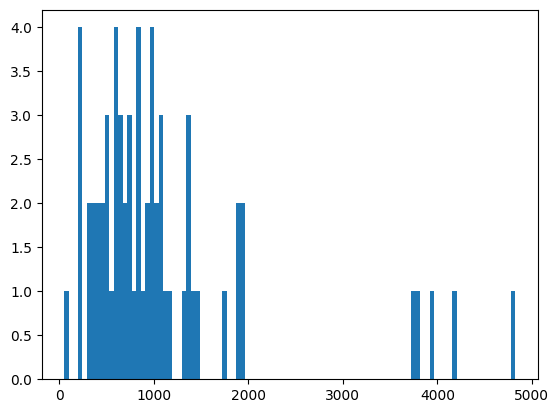

In [25]:
# With changes to prompt
import os
from transformers import AutoTokenizer
from datasets import load_dataset
# Load tokenizer for pre-training formatting
tokenizer = AutoTokenizer.from_pretrained("nvidia/Llama-3.1-Nemotron-Nano-8B-v1")
# ds = ds.map(lambda x: {'token_size': len(tokenizer.encode(x['document']))}, batched=False, num_proc=16)

new_ds = new_ds.map(lambda x: {'token_size': len(tokenizer.encode(x['document']))}, batched=False, num_proc=16)
# Plot the distribution of SEC filings data for 3M
import matplotlib.pyplot as plt
plt.hist(new_ds['token_size'], bins=100)
plt.show()

In [23]:
new_ds.to_json("seed_data.jsonl", orient="records", lines=True)

Creating json from Arrow format: 100%|██████████| 1/1 [00:00<00:00, 116.92ba/s]


1099013

### Data formatting

In [50]:
from datasets import load_dataset, concatenate_datasets
import os
fp = ["/new_data/knowledge_rh/sdg_hub_knowledge_bot/knowledge_generation_v0_6_3/slides_paper_seed_data/", 
"/new_data/knowledge_rh/sdg_hub_knowledge_bot/knowledge_generation_v0_6_3/notebooks_seed_data",
"/new_data/knowledge_rh/sdg_hub_knowledge_bot/knowledge_generation_v0_6_3/seed_data",
"/new_data/knowledge_rh/sdg_hub_knowledge_bot/knowledge_generation_v0_6_3_2/slides_paper_seed_data/",
"/new_data/knowledge_rh/sdg_hub_knowledge_bot/knowledge_generation_v0_6_3_2/notebooks_seed_data/",
"/new_data/knowledge_rh/sdg_hub_knowledge_bot/knowledge_generation_v0_6_3_2/seed_data/"]
ds = []
for e in fp:
    ds.append(load_dataset("json", data_dir=e, split="train"))
    print(e)
    print(ds[-1])
    print(len(set(ds[-1]['raw_document'])))
ds = concatenate_datasets(ds)
ds = ds.filter(lambda x: x['type']  != 'git_history')
ds = ds.filter(lambda x: x['judgment'] == 'YES')
ds = ds.filter(lambda x: x['question'].strip() != '')
ds = ds.filter(lambda x: '[Question]'.lower() not in x['response'].lower())
ds = ds.map(lambda x: {'response': x['response'].replace('[END]', '').replace('[End]', '').strip()}, num_proc=10)
ds = ds.map(lambda x: {'response': x['response'].replace('[ANSWER]', '').replace('[Answer]', '').strip()}, num_proc=10)

### Temporary
ds = ds.filter(lambda x: '<think>' not in x['raw_document'])
ds = ds.filter(lambda x: x['document'].count('<think>')  <= 1)
ds = ds.map(lambda x: {'document': x['document'].split('</think>')[1].strip() if '</think>' in  x['document'] else x['document']})
ds

/new_data/knowledge_rh/sdg_hub_knowledge_bot/knowledge_generation_v0_6_3/slides_paper_seed_data/
Dataset({
    features: ['raw_document', 'type', 'domain', 'token_size', 'document_outline', 'icl_document', 'icl_query_1', 'icl_response_1', 'icl_query_2', 'icl_response_2', 'icl_query_3', 'icl_response_3', 'dataset_type', 'document', 'question', 'response', 'explanation', 'judgment'],
    num_rows: 11994
})
13
/new_data/knowledge_rh/sdg_hub_knowledge_bot/knowledge_generation_v0_6_3/notebooks_seed_data
Dataset({
    features: ['document_outline', 'raw_document', 'type', 'domain', 'icl_document', 'icl_query_1', 'icl_response_1', 'icl_query_2', 'icl_response_2', 'icl_query_3', 'icl_response_3', 'token_size', 'dataset_type', 'document', 'question', 'response', 'explanation', 'judgment'],
    num_rows: 6046
})
11
/new_data/knowledge_rh/sdg_hub_knowledge_bot/knowledge_generation_v0_6_3/seed_data
Dataset({
    features: ['document_outline', 'raw_document', 'type', 'domain', 'icl_document', 'icl_

Map: 100%|██████████| 84184/84184 [00:21<00:00, 3894.09 examples/s]


Dataset({
    features: ['raw_document', 'type', 'domain', 'token_size', 'document_outline', 'icl_document', 'icl_query_1', 'icl_response_1', 'icl_query_2', 'icl_response_2', 'icl_query_3', 'icl_response_3', 'dataset_type', 'document', 'question', 'response', 'explanation', 'judgment'],
    num_rows: 84184
})

Map (num_proc=16): 100%|██████████| 77966/77966 [00:22<00:00, 3440.39 examples/s]


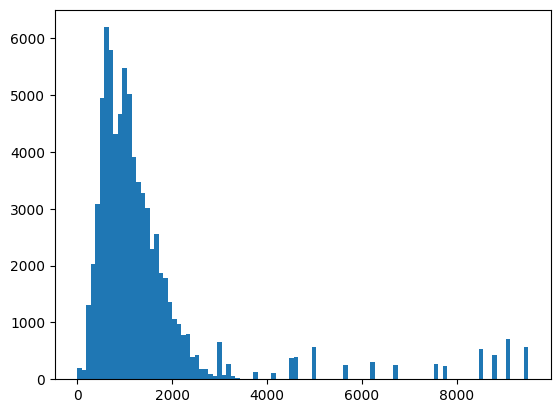

In [10]:
# With changes to prompt
import os
from transformers import AutoTokenizer
from datasets import load_dataset
# Load tokenizer for pre-training formatting
tokenizer = AutoTokenizer.from_pretrained("nvidia/Llama-3.1-Nemotron-Nano-8B-v1")
ds = ds.map(lambda x: {'token_size': len(tokenizer.encode(x['document']))}, batched=False, num_proc=16)
# Plot the distribution of SEC filings data for 3M
import matplotlib.pyplot as plt
plt.hist(ds['token_size'], bins=100)
plt.show()

In [43]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from knowledge_utils import generate_knowledge_qa_dataset

In [51]:
from datasets import Dataset, concatenate_datasets
def backpro_mix(ds, backpro_threshold=3):
    ds = ds.map(lambda x: {'response': x['response'].replace('[END]', '').replace('[ANSWER]', '').strip()}, num_proc=10)
    backpro_docs = []
    backpro_docs_dict = {}
    don_t_backpro_docs = []
    for i, doc in enumerate(ds['document']):
        if doc not in backpro_docs_dict:
            backpro_docs_dict[doc] = 1
        else:
            backpro_docs_dict[doc] += 1
        if backpro_docs_dict[doc] < backpro_threshold+1:
            backpro_docs.append(ds[i])
            backpro_docs[-1]['unmask'] = True
        else:
            don_t_backpro_docs.append(ds[i])
            don_t_backpro_docs[-1]['unmask'] = False
    ds_new = concatenate_datasets([Dataset.from_list(backpro_docs), Dataset.from_list(don_t_backpro_docs)])
    return ds_new

ds_ = backpro_mix(ds, backpro_threshold=3)
ds_.filter(lambda x: x['unmask'])

Filter: 100%|██████████| 84184/84184 [00:02<00:00, 35215.41 examples/s]


Dataset({
    features: ['raw_document', 'type', 'domain', 'token_size', 'document_outline', 'icl_document', 'icl_query_1', 'icl_response_1', 'icl_query_2', 'icl_response_2', 'icl_query_3', 'icl_response_3', 'dataset_type', 'document', 'question', 'response', 'explanation', 'judgment', 'unmask'],
    num_rows: 24188
})

In [52]:
knowl_train = generate_knowledge_qa_dataset(ds_.filter(lambda x: x['unmask']), keep_context_separate=False, keep_document_outline=True, 
keep_columns=['document', 'document_outline', 'raw_document'])
print(knowl_train)
knowl_train = knowl_train.map(lambda x: {'unmask': True})
# knowl_train.to_json("/new_data/knowledge_rh/sdg_hub_knowledge_bot/training_mix/knowledge_generation_v0_7_n3.jsonl", orient="records", lines=True)
# v0.7 generated using qwen3-32b with thinking on

Map: 100%|██████████| 24188/24188 [00:05<00:00, 4080.83 examples/s]


Dataset({
    features: ['raw_document', 'document_outline', 'document', 'messages', 'metadata', 'id'],
    num_rows: 24188
})


Map: 100%|██████████| 24188/24188 [00:01<00:00, 15309.38 examples/s]


In [53]:
knowl_train_ = knowl_train.map(lambda x: {'think_response': x['messages'][1]['content'].split("\n</think>\n\n")})
# pb = knowl_train_.filter(lambda x: len(x['think_response']) != 2)
knowl_train_ = knowl_train_.filter(lambda x: len(x['think_response']) == 2)
knowl_train = knowl_train_.map(lambda x: {'messages': x['messages'][:1] + [{'role': 'assistant','reasoning_content': x['think_response'][0].replace('<think>', ''),  'content': x['think_response'][1].strip()}]}).remove_columns(['think_response'])
knowl_train.to_json("/new_data/knowledge_rh/sdg_hub_knowledge_bot/training_mix/knowledge_generation_v0_7_n3.jsonl", orient="records", lines=True)


Creating json from Arrow format: 100%|██████████| 25/25 [00:05<00:00,  4.65ba/s]


936655498

Map (num_proc=16): 100%|██████████| 24027/24027 [00:23<00:00, 1044.18 examples/s]


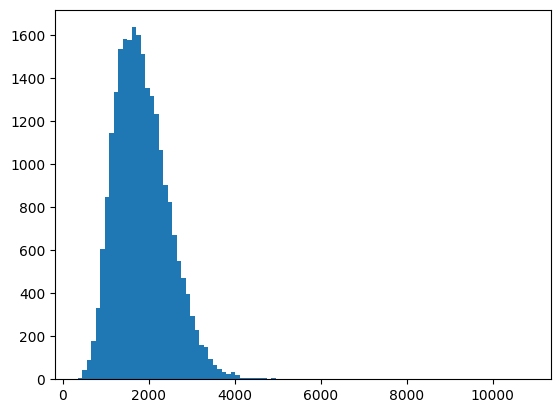

In [27]:
# With changes to prompt
import os
from transformers import AutoTokenizer
from datasets import load_dataset
# Load tokenizer for pre-training formatting
tokenizer = AutoTokenizer.from_pretrained("nvidia/Llama-3.1-Nemotron-Nano-8B-v1")
knowl_train = knowl_train.map(lambda x: {'token_size': len(tokenizer.encode(x['messages'][0]['content'] + x['messages'][1]['content']))}, batched=False, num_proc=16)
# Plot the distribution of SEC filings data for 3M
import matplotlib.pyplot as plt
plt.hist(knowl_train['token_size'], bins=100)
plt.show()

In [34]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-32B-Instruct")
tokenizer.chat_template

'{%- if tools %}\n    {{- \'<|im_start|>system\\n\' }}\n    {%- if messages[0][\'role\'] == \'system\' %}\n        {{- messages[0][\'content\'] }}\n    {%- else %}\n        {{- \'You are Qwen, created by Alibaba Cloud. You are a helpful assistant.\' }}\n    {%- endif %}\n    {{- "\\n\\n# Tools\\n\\nYou may call one or more functions to assist with the user query.\\n\\nYou are provided with function signatures within <tools></tools> XML tags:\\n<tools>" }}\n    {%- for tool in tools %}\n        {{- "\\n" }}\n        {{- tool | tojson }}\n    {%- endfor %}\n    {{- "\\n</tools>\\n\\nFor each function call, return a json object with function name and arguments within <tool_call></tool_call> XML tags:\\n<tool_call>\\n{\\"name\\": <function-name>, \\"arguments\\": <args-json-object>}\\n</tool_call><|im_end|>\\n" }}\n{%- else %}\n    {%- if messages[0][\'role\'] == \'system\' %}\n        {{- \'<|im_start|>system\\n\' + messages[0][\'content\'] + \'<|im_end|>\\n\' }}\n    {%- else %}\n       

In [1]:
from datasets import load_dataset
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-Coder-7B-Instruct")

fp = "/new_data/knowledge_rh/sdg_hub_knowledge_bot/training_mix/knowledge_generation_v0_4_n3.jsonl"
ds = load_dataset("json", data_files=fp, split='train')

/home/lab/.conda/envs/sdg/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ds = ds.map(lambda x: {'len': len(tokenizer.apply_chat_template(x['messages'], tokenize=True))})

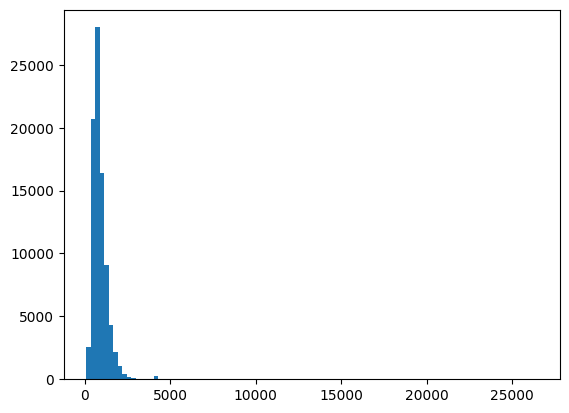

In [10]:
# With changes to prompt
import os
from transformers import AutoTokenizer
from datasets import load_dataset
# Load tokenizer for pre-training formatting
import matplotlib.pyplot as plt
plt.hist(ds['len'], bins=100)
plt.show()

In [30]:
ds_ = ds.filter(lambda x: x['len'] > 15000)

Filter: 100%|██████████| 85894/85894 [00:01<00:00, 71398.87 examples/s]


In [31]:
ds_.filter(lambda x: 'Git History' not in x['messages'][0]['content'])

Filter: 100%|██████████| 129/129 [00:00<00:00, 15834.97 examples/s]


Dataset({
    features: ['messages', 'metadata', 'id', 'unmask', 'len'],
    num_rows: 0
})

In [19]:
import pandas as pd
from datasets import Dataset
# read xlsx file
df = pd.read_excel('/home/lab/abhi/sdg_hub_pr_139_docs/examples/knowledge_tuning/sdg_hub_knowledge_bot/eval_data/SDG_HUB Eval Dataset.xlsx')
# Delete name column
df = df.drop(columns=['name'])
ds = Dataset.from_pandas(df)
ds.to_json("/home/lab/abhi/sdg_hub_pr_139_docs/examples/knowledge_tuning/sdg_hub_knowledge_bot/eval_data/SDG_HUB_Eval_Dataset.jsonl", orient="records", lines=True)


Creating json from Arrow format: 100%|██████████| 1/1 [00:00<00:00, 777.30ba/s]


12731

In [2]:
from datasets import load_dataset

ds = load_dataset("json", data_files="/home/lab/abhi/sdg_hub_pr_139_docs/examples/knowledge_tuning/sdg_hub_knowledge_bot/eval_data/quality-sdg_hub_knowledge_v0_6-lr5e-06-rr0.1-epochs2-bs16-wd0.01-warmup0.05-Qwen2.57BInstruct_eval.jsonl", split='train') 

In [5]:
print(ds[10]['generated_response'])

Context-aware chunking is a technique in data processing where information is segmented into manageable chunks, taking into account the specific context or environment in which the data will be used. This approach enhances efficiency and relevance by tailoring the data structure to fit the particular circumstances.

We need context-aware chunking because:

1. **Improved Relevance**: By considering the context, the chunks can be more relevant to the intended use, leading to better performance and decision-making.
2. **Efficiency**: Context-aware chunking optimizes storage and processing by aligning the granularity of data segments with the needs of the application.
3. **Scalability**: It allows for more flexible and scalable data management, accommodating varying requirements across different scenarios.
4. **Enhanced Security**: Understanding the context helps in applying appropriate security measures to different data segments.
5. **Better User Experience**: In applications like mobile

In [7]:
ds.to_csv("/home/lab/abhi/sdg_hub_pr_139_docs/examples/knowledge_tuning/sdg_hub_knowledge_bot/eval_data/quality-sdg_hub_knowledge_v0_6-lr5e-06-rr0.1-epochs2-bs16-wd0.01-warmup0.05-Qwen2.57BInstruct_eval.csv")

Creating CSV from Arrow format: 100%|██████████| 1/1 [00:00<00:00, 171.55ba/s]


77356

In [3]:
from datasets import load_dataset
fp = "/new_data/knowledge_rh/sdg_hub_knowledge_bot/knowledge_generation_v0_6_2/seed_data/"
ds = load_dataset("json", data_dir=fp, split='train')

In [4]:
set(ds['dataset_type'])

{'base_document',
 'summary_atomic_facts',
 'summary_detailed',
 'summary_extractive'}

In [5]:
len(set(ds.filter(lambda x: x['dataset_type'] == 'summary_extractive')['document']))

Filter: 100%|██████████| 91632/91632 [00:01<00:00, 47016.04 examples/s]


3200

In [6]:
len(set(ds.filter(lambda x: x['dataset_type'] == 'summary_detailed')['document']))

Filter: 100%|██████████| 91632/91632 [00:01<00:00, 50060.63 examples/s]


3200

In [9]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-32B-Instruct")

In [8]:
tokenizer.apply_chat_template([{'role': 'system', 'content': 'You are a helpful assistant.'}, {'role': 'user', 'content': 'What is the capital of France?'}], 
tokenize=False, enable_thinking=False, add_generation_prompt=True)

'<|im_start|>system\nYou are a helpful assistant.<|im_end|>\n<|im_start|>user\nWhat is the capital of France?<|im_end|>\n<|im_start|>assistant\n<think>\n\n</think>\n\n'